# Лабораторна 9 — Оцінка густини


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 9  
**Тема лабораторної:** Оцінка густини

## Цілі лабораторної

- 1D розминка: гістограма проти KDE 
- Ефект пропускної здатності (bandwidth)
- KDE у двох вимірах 
- Навчання GMM та крива вірогідності 
- GMM проти KDE на одних і тих самих даних 
- Виявлення аномалій через оцінку логарифму щільності 

## Налаштування середовища

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import importlib
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import norm
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture

import density_estimation_student as de
importlib.reload(de)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

SEED   = 42
COLORS = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#762A83",
          "#A6DBA0", "#C2A5CF", "#E08214"]
np.random.seed(SEED)


---
## 1. - 1D розминка: гістограма проти KDE

Починаємо з одновимірного прикладу, де результат легко інтерпретувати візуально.
Наш власний `KDE` повинен генерувати такий самий результат, як `sklearn.KernelDensity`.

**Датасет:** двомодальна суміш двох гаусіан з різними центрами і дисперсіями:

$$X \sim 0.45\,\mathcal{N}(-2,\,0.8^2) + 0.55\,\mathcal{N}(3,\,1.2^2)$$

**Bandwidth за правилом Сільвермана:**
$$h^* = 1.06 \cdot \hat{\sigma} \cdot n^{-1/5}$$

де $\hat{\sigma}$ - вибіркове стандартне відхилення.

#### Генерація датасету та підгонка KDE

Генеруємо 400 одновимірних точок, обчислюємо bandwidth за правилом Сільвермана,
навчаємо власний KDE та еталонний sklearn KDE, а потім обчислюємо значення
щільності на рівномірній сітці для побудови графіка.

> **Примітка:** `KDE.score_samples` вже реалізована, але всередині вона викликає
> `_log_gaussian_kernel` — ваш перший TODO. Реалізуйте його, щоб цей блок запрацював.

In [15]:
rng = np.random.RandomState(SEED)

# Bimodal 1D dataset
n1, n2 = 180, 220
X_1d   = np.concatenate([rng.normal(-2.0, 0.8, n1),
                          rng.normal( 3.0, 1.2, n2)])

# Silverman bandwidth
h_s = 1.06 * X_1d.std() * len(X_1d) ** (-0.2)
print(f"Silverman bandwidth: h = {h_s:.4f}")

x_eval_1d = np.linspace(-6, 8, 500)

# Student KDE
kde_student = de.KDE(bandwidth=h_s)
kde_student.fit(X_1d[:, None])
log_dens_student = kde_student.score_samples(x_eval_1d[:, None])
dens_student     = np.exp(log_dens_student)

# Reference: sklearn KDE
kde_ref = KernelDensity(bandwidth=h_s, kernel="gaussian")
kde_ref.fit(X_1d[:, None])
dens_ref = np.exp(kde_ref.score_samples(x_eval_1d[:, None]))

# Max absolute error between student and reference
max_err = np.max(np.abs(dens_student - dens_ref))
print(f"Max absolute error (student vs sklearn): {max_err:.2e}")

Silverman bandwidth: h = 0.8704
Max absolute error (student vs sklearn): 3.83e-15


#### Порівняння: гістограма, власний KDE та sklearn KDE

Будуємо три варіанти оцінки на одному графіку: гістограму (для наочності),
власну реалізацію KDE та еталонну sklearn. Якщо реалізація правильна, криві
студентського та sklearn KDE повинні збігатися.

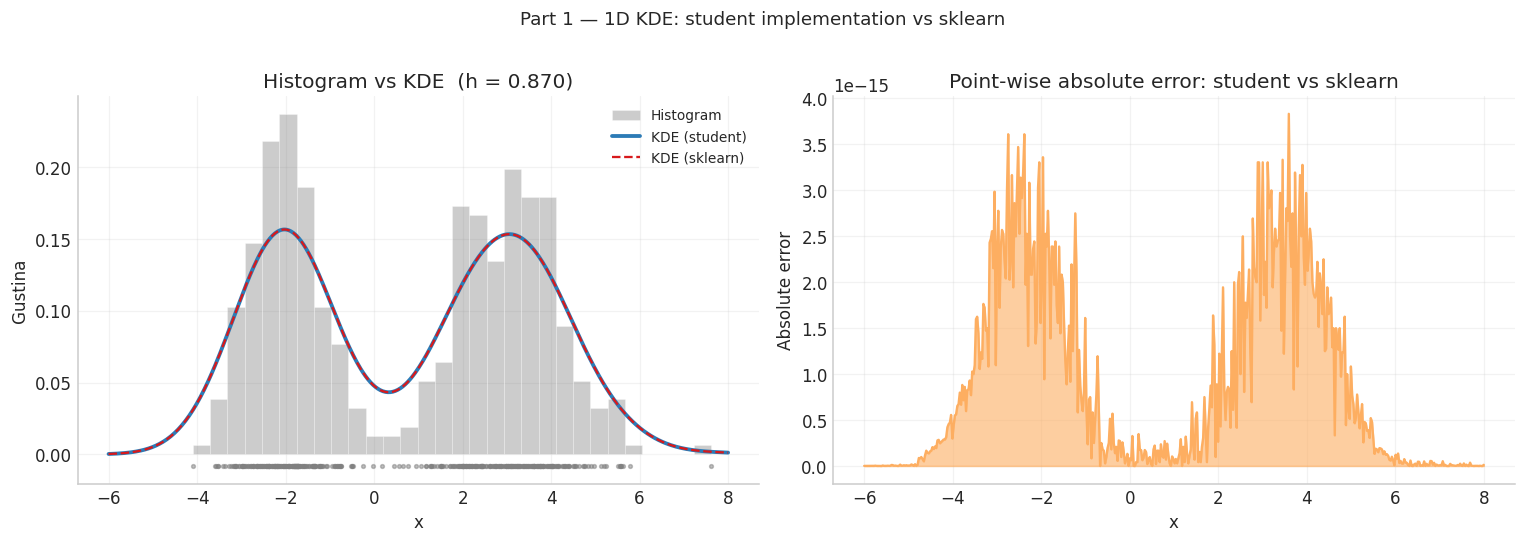

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram vs KDE comparison
axes[0].hist(X_1d, bins=30, density=True, alpha=0.4,
             color="gray", edgecolor="white", lw=0.5, label="Histogram")
axes[0].plot(x_eval_1d, dens_student, color=COLORS[0], lw=2.5,
             label="KDE (student)")
axes[0].plot(x_eval_1d, dens_ref, color=COLORS[1], lw=1.5,
             linestyle="--", label="KDE (sklearn)")
axes[0].scatter(X_1d, np.full_like(X_1d, -0.008),
                color="gray", s=6, alpha=0.5, zorder=5)
axes[0].set_xlabel("x"); axes[0].set_ylabel("Gustina")
axes[0].set_title(f"Histogram vs KDE  (h = {h_s:.3f})")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

# Right: absolute error between student and reference
axes[1].fill_between(x_eval_1d, np.abs(dens_student - dens_ref),
                     alpha=0.6, color=COLORS[3])
axes[1].plot(x_eval_1d, np.abs(dens_student - dens_ref),
             color=COLORS[3], lw=1.5)
axes[1].set_xlabel("x"); axes[1].set_ylabel("Absolute error")
axes[1].set_title("Point-wise absolute error: student vs sklearn")
axes[1].grid(alpha=0.25)

plt.suptitle("Part 1 — 1D KDE: student implementation vs sklearn", fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 1

- Якщо реалізація `score_samples` правильна, максимальна абсолютна похибка
  відносно sklearn повинна бути порядку $10^{-14}$ (лише похибки округлення).
- Порівняно з гістограмою, KDE дає **неперервну** і **гладку** оцінку, яка
  добре відтворює обидва піки двомодального розподілу.
- Ефект "розмазування" ядром помітний на хвостах: KDE ненульовий навіть трохи
  поза межами вибірки, що відповідає невизначеності оцінки.

---
## 2. - Ефект пропускної здатності (bandwidth)

Bandwidth $h$ контролює компроміс між **зсувом** (bias) та **дисперсією** (variance)
оцінки:

- Мала $h$ - низький зсув, висока дисперсія (реакція на шум у даних).
- Велика $h$ - високий зсув, низька дисперсія (надмірне згладжування).

Порівняємо вашу реалізацію KDE при чотирьох значеннях bandwidth.

#### Обчислення щільностей при різних bandwidth

Навчаємо KDE при чотирьох значеннях $h$: $0.05$, $0.25$, значення Сільвермана
та $2.0$. Для кожного оцінюємо щільність на тій самій сітці.

In [17]:
bandwidths  = [0.05, 0.25, h_s, 2.0]
bw_labels   = [f"h=0.05 (under-smooth)", f"h=0.25",
               f"h={h_s:.2f} (Silverman)", f"h=2.00 (over-smooth)"]
bw_colors   = [COLORS[1], COLORS[2], COLORS[0], COLORS[3]]

dens_bw = {}
for h, lbl in zip(bandwidths, bw_labels):
    kde_h = de.KDE(bandwidth=h)
    kde_h.fit(X_1d[:, None])
    dens_bw[lbl] = np.exp(kde_h.score_samples(x_eval_1d[:, None]))

#### Графік: density curves for four bandwidth values

Відображаємо всі чотири криві на одному графіку разом із гістограмою даних.
Оптимальна ширина повинна відтворювати обидва піки, не виявляючи "скачків"
від окремих точок і не зливаючи піки в один.

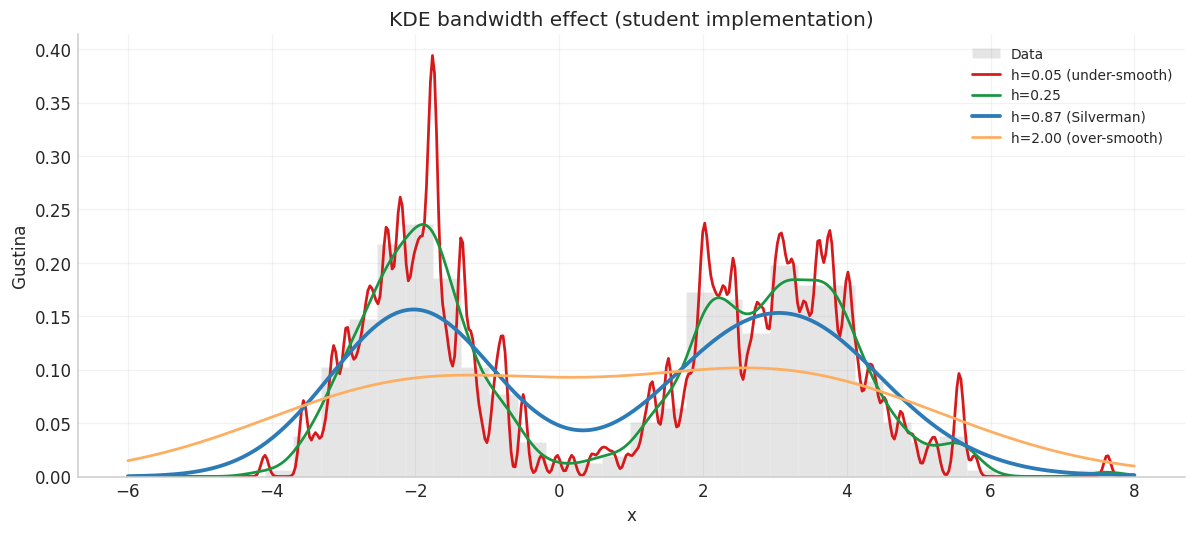

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(X_1d, bins=30, density=True, alpha=0.2,
        color="gray", edgecolor="white", lw=0.4, label="Data")

for lbl, dens_h, col in zip(bw_labels, dens_bw.values(), bw_colors):
    lw = 2.5 if "Silverman" in lbl else 1.8
    ax.plot(x_eval_1d, dens_h, lw=lw, color=col, label=lbl)

ax.set_xlabel("x"); ax.set_ylabel("Gustina")
ax.set_title("KDE bandwidth effect (student implementation)")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

#### Результати Part 2

- При $h = 0.05$ крива надто нерівна: видно окремі "голки" навколо кожної точки даних.
- При $h = 0.25$ форма стає гладкою і обидва піки добре розрізнені.
- При значенні Сільвермана ($h \approx 0.3$) результат близький до $h = 0.25$,
  але отриманий автоматично без підбору.
- При $h = 2.0$ обидва піки зливаються в один широкий горб - структура розподілу
  прихована.

---
## 3. - KDE у двох вимірах

Перевіряємо, що реалізація `score_samples` коректно працює і для $d = 2$.
Двовимірний KDE обчислює щільність як **добуток одновимірних ядер** по кожній
координаті (ізотропне ядро).

**Датасет:** `make_moons` - два "місяці", класичний нелінійно роздільний набір.
Він цікавий тим, що справжній розподіл явно не гаусівський.

#### Підгонка KDE та обчислення щільності на сітці

Нормалізуємо дані, обчислюємо Silverman bandwidth для 2D
($h = 1.06 \cdot \hat{\sigma} \cdot n^{-1/5}$ де $\hat{\sigma}$ береться
по першому виміру), навчаємо KDE і обчислюємо значення щільності на сітці
$150 \times 150$ для побудови теплової карти.

In [19]:
X_moon, y_moon = make_moons(n_samples=500, noise=0.15, random_state=SEED)
X_moon = StandardScaler().fit_transform(X_moon)

h_2d   = 1.06 * X_moon[:, 0].std() * len(X_moon) ** (-0.2)

kde_2d_student = de.KDE(bandwidth=h_2d)
kde_2d_student.fit(X_moon)

# Build evaluation grid
x1g  = np.linspace(X_moon[:, 0].min() - 0.4, X_moon[:, 0].max() + 0.4, 150)
x2g  = np.linspace(X_moon[:, 1].min() - 0.4, X_moon[:, 1].max() + 0.4, 150)
X1G, X2G = np.meshgrid(x1g, x2g)
grid_2d  = np.c_[X1G.ravel(), X2G.ravel()]

log_Z = kde_2d_student.score_samples(grid_2d)
Z     = np.exp(log_Z).reshape(X1G.shape)

# Reference density from sklearn
kde_2d_ref = KernelDensity(bandwidth=h_2d, kernel="gaussian").fit(X_moon)
Z_ref = np.exp(kde_2d_ref.score_samples(grid_2d)).reshape(X1G.shape)

max_err_2d = np.max(np.abs(Z - Z_ref))
print(f"Max absolute error 2D (student vs sklearn): {max_err_2d:.2e}")

Max absolute error 2D (student vs sklearn): 3.23e-15


#### Візуалізація: теплова карта та ізолінії щільності

Будуємо два графіки: теплову карту заповнених ізоліній (contourf) і лише ізолінії
з розсіяними точками даних. Щільність повинна мати два окремі горби -
по одному на кожен "місяць".

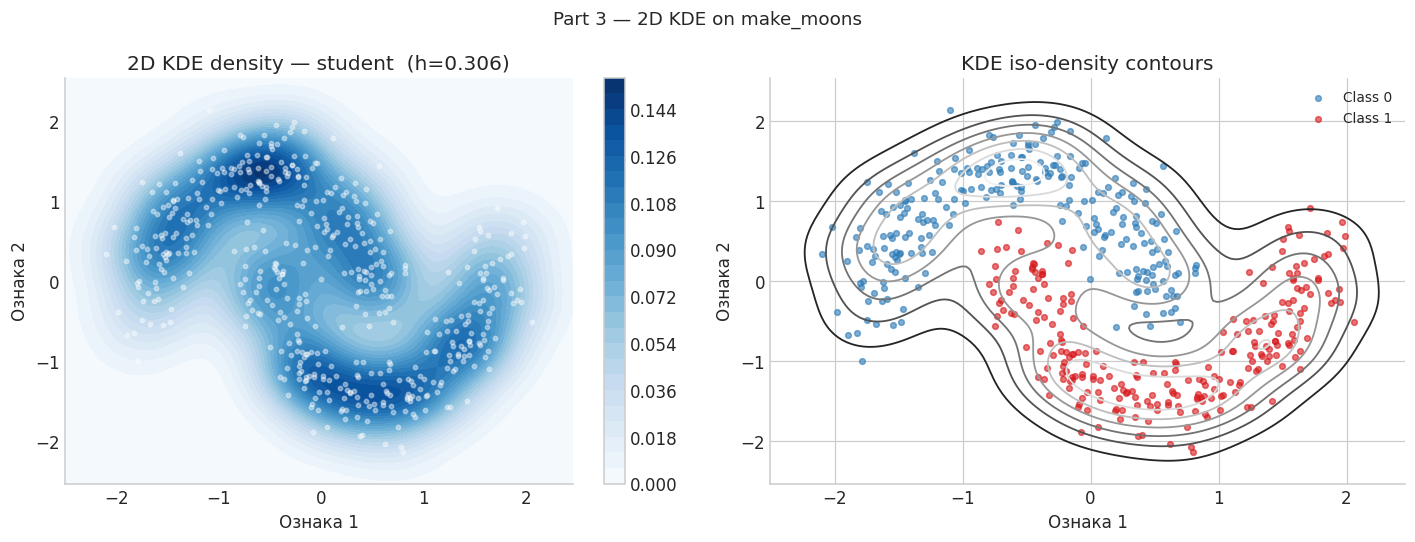

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: filled contour
cf = axes[0].contourf(X1G, X2G, Z, levels=25, cmap="Blues")
axes[0].scatter(X_moon[:, 0], X_moon[:, 1],
                s=8, color="white", alpha=0.4, zorder=5)
plt.colorbar(cf, ax=axes[0])
axes[0].set_xlabel("Ознака 1"); axes[0].set_ylabel("Ознака 2")
axes[0].set_title(f"2D KDE density — student  (h={h_2d:.3f})")

# Right: contours + coloured data points
for c, col in zip([0, 1], [COLORS[0], COLORS[1]]):
    mask = y_moon == c
    axes[1].scatter(X_moon[mask, 0], X_moon[mask, 1],
                    s=14, color=col, alpha=0.6, label=f"Class {c}")
axes[1].contour(X1G, X2G, Z, levels=8, cmap="Greys_r", linewidths=1.2)
axes[1].set_xlabel("Ознака 1"); axes[1].set_ylabel("Ознака 2")
axes[1].set_title("KDE iso-density contours")
axes[1].legend(fontsize=9)

plt.suptitle("Part 3 — 2D KDE on make_moons", fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 3

- Щільність правильно формує два окремі горби, що відповідають двом "місяцям".
- KDE не знає про структуру класів (він ненавчений), але ізолінії добре
  відповідають межам між класами - це ілюструє зв'язок густини з класифікацією.
- Мінімуми щільності між "місяцями" могли б слугувати пороговим значенням
  для виявлення аномалій (Part 6).

---
## 4. - Навчання GMM та крива вірогідності

Перевіряємо реалізацію GMM. Алгоритм EM (E-крок і M-крок) **вже реалізований**
у наданому коді — ваше завдання полягає в тому, щоб реалізувати `score_samples`
і `predict`, які використовуються після навчання.

Навчимо GMM на двовимірних даних з трьома кластерами і перевіримо:

1. Чи монотонно зростає логарифм вірогідності при ітераціях?
   (Для цього потрібен ваш `score_samples`.)
2. Чи збігаються знайдені центри з реальними?
3. Чи відповідають еліпси коваріацій формі кластерів?
   (Для кольорування точок потрібен ваш `predict`.)

**Датасет:** `make_blobs` з трьома кластерами різної форми.

#### Генерація даних та навчання GMM

Генеруємо 350 точок трьох кластерів, нормалізуємо і навчаємо GMM із $K = 3$.
Паралельно запускаємо sklearn GMM для порівняння.

In [21]:
X_blobs, y_blobs = make_blobs(
    n_samples=350,
    centers=[[-3, 0], [1, 3], [3, -2]],
    cluster_std=[0.8, 1.1, 0.6],
    random_state=SEED
)
X_blobs = StandardScaler().fit_transform(X_blobs)

# Student GMM
gmm_student = de.GMM(n_components=3, n_iter=200, random_state=SEED)
gmm_student.fit(X_blobs)

# Reference: sklearn GMM
gmm_sklearn = GaussianMixture(n_components=3, n_init=1, random_state=SEED)
gmm_sklearn.fit(X_blobs)

print("Student GMM - final log-likelihood per point:",
      gmm_student.score_samples(X_blobs).mean().round(4))
print("sklearn GMM  - final log-likelihood per point:",
      gmm_sklearn.score_samples(X_blobs).mean().round(4))
print(f"\nEM iterations (student): {len(gmm_student.log_likelihood_curve_)}")

Student GMM - final log-likelihood per point: -1.6722
sklearn GMM  - final log-likelihood per point: -1.6722

EM iterations (student): 12


#### Візуалізація: крива вірогідності та коваріаційні еліпси

Будуємо два графіки: зліва - логарифм вірогідності по ітераціях EM (повинен
монотонно зростати), справа - двовимірний розсіювальний графік із коваріаційними
еліпсами знайдених компонент.

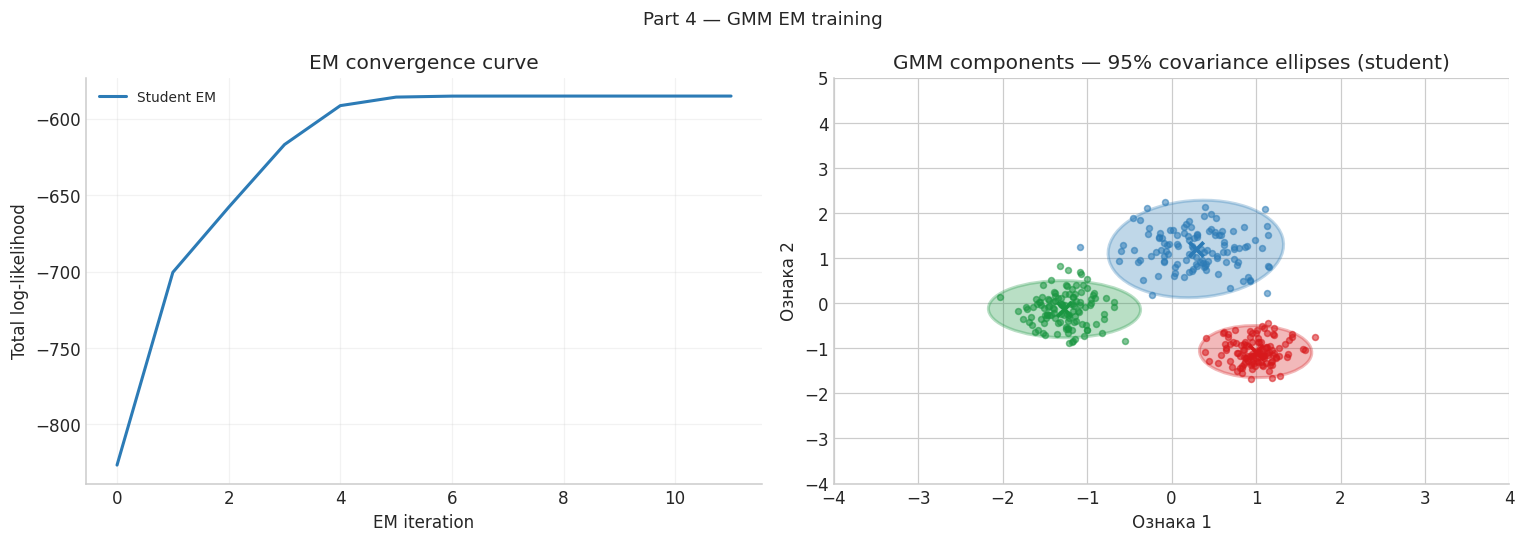

In [22]:
def draw_ellipses(ax, means, covs, colors, alpha=0.30, lw=2.0):
    """Draw 95% confidence ellipses for GMM components."""
    for mu, cov, col in zip(means, covs, colors):
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvals = np.maximum(eigvals, 1e-8)            # numerical safety
        angle   = np.degrees(np.arctan2(*eigvecs[:, 1][::-1]))
        width   = 2 * 2.45 * np.sqrt(eigvals[0])
        height  = 2 * 2.45 * np.sqrt(eigvals[1])
        ell     = Ellipse(xy=mu, width=width, height=height, angle=angle,
                          edgecolor=col, facecolor=col, alpha=alpha,
                          linewidth=lw, zorder=4)
        ax.add_patch(ell)
        ax.scatter(*mu, color=col, s=90, marker="x", zorder=6,
                   linewidths=2.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log-likelihood curve
ll_student = gmm_student.log_likelihood_curve_

axes[0].plot(ll_student, color=COLORS[0], lw=2, label="Student EM")

axes[0].set_xlabel("EM iteration")
axes[0].set_ylabel("Total log-likelihood")
axes[0].set_title("EM convergence curve")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

# Right: scatter + ellipses
ell_colors = [COLORS[0], COLORS[1], COLORS[2]]
labels_pred = gmm_student.predict(X_blobs)

for c, col in enumerate(ell_colors):
    mask = labels_pred == c
    axes[1].scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                    s=15, color=col, alpha=0.55)

draw_ellipses(axes[1], gmm_student.means_, gmm_student.covariances_, ell_colors)
axes[1].set_xlabel("Ознака 1"); axes[1].set_ylabel("Ознака 2")
axes[1].set_title("GMM components — 95% covariance ellipses (student)")
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 5)

plt.suptitle("Part 4 — GMM EM training", fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 4

- Якщо `_e_step` і `_m_step` реалізовані правильно, крива вірогідності буде
  монотонно зростати і збігатися до того самого значення, що й еталонна.
- Еліпси коваріацій студентського GMM повинні відповідати еліпсам рішення.
- Кут нахилу і форма еліпса відображають коваріацію між координатами всередині
  кожного кластера - наочна перевірка коректності M-кроку.

---
## 5. - GMM проти KDE на одних і тих самих даних

Порівняємо два підходи до оцінки щільності на двовимірному датасеті:

- **KDE** — повністю непараметрична оцінка, не робить припущень про форму.
- **GMM** — параметрична модель, яка виражає щільність як суму гаусіан.

Яка модель краще передає справжню структуру розподілу при однаковому $n$?
Де кожна перевершує іншу?

#### Обчислення та порівняння поверхонь щільності

На одних і тих самих даних `make_blobs` навчаємо KDE (bandwidth Сільвермана) і
GMM з $K = 3$ (студентська реалізація). Оцінюємо щільності на тій самій сітці
і будуємо side-by-side теплові карти.

> **Примітка:** `GMM.sample` вже реалізована. `KDE.sample` — ваш другий TODO.

In [23]:
# Shared evaluation grid
x1g_c = np.linspace(X_blobs[:, 0].min() - 0.5, X_blobs[:, 0].max() + 0.5, 140)
x2g_c = np.linspace(X_blobs[:, 1].min() - 0.5, X_blobs[:, 1].max() + 0.5, 140)
X1C, X2C = np.meshgrid(x1g_c, x2g_c)
grid_c   = np.c_[X1C.ravel(), X2C.ravel()]

# KDE density
h_c     = 1.06 * X_blobs[:, 0].std() * len(X_blobs) ** (-0.2)
kde_c   = de.KDE(bandwidth=h_c)
kde_c.fit(X_blobs)
Z_kde   = np.exp(kde_c.score_samples(grid_c)).reshape(X1C.shape)

# GMM density
Z_gmm   = np.exp(gmm_student.score_samples(grid_c)).reshape(X1C.shape)

#### Графік: side-by-side comparison та семплування

Будуємо три графіки: щільність KDE, щільність GMM і порівняння семплів,
згенерованих кожним методом. Семплування перевіряє методи `KDE.sample` та `GMM.sample`.

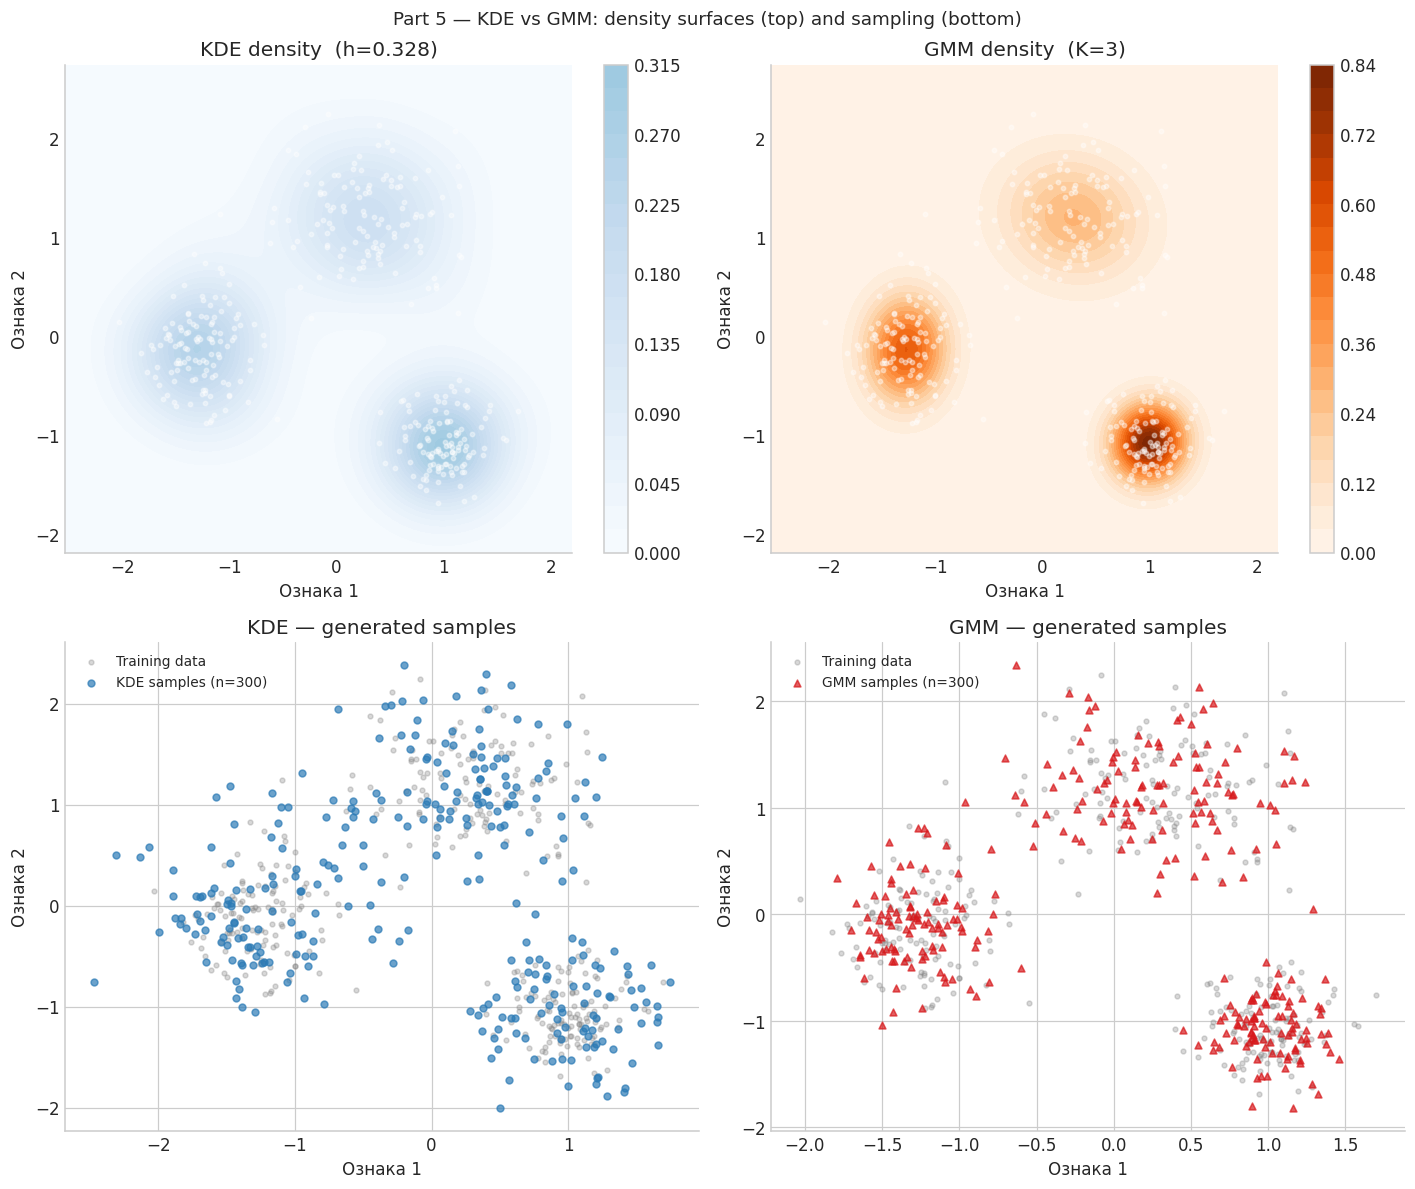

In [24]:
# %%
# Shared evaluation grid
x1g_c = np.linspace(X_blobs[:, 0].min() - 0.5, X_blobs[:, 0].max() + 0.5, 140)
x2g_c = np.linspace(X_blobs[:, 1].min() - 0.5, X_blobs[:, 1].max() + 0.5, 140)
X1C, X2C = np.meshgrid(x1g_c, x2g_c)
grid_c   = np.c_[X1C.ravel(), X2C.ravel()]

# KDE density
h_c   = 1.06 * X_blobs[:, 0].std() * len(X_blobs) ** (-0.2)
kde_c = de.KDE(bandwidth=h_c)
kde_c.fit(X_blobs)
Z_kde = np.exp(kde_c.score_samples(grid_c)).reshape(X1C.shape)

# GMM density
Z_gmm = np.exp(gmm_student.score_samples(grid_c)).reshape(X1C.shape)

# Samples from each model
kde_samples = kde_c.sample(300, random_state=SEED)
gmm_samples = gmm_student.sample(300)

vmin = min(Z_kde.min(), Z_gmm.min())
vmax = max(Z_kde.max(), Z_gmm.max())

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# Top left: KDE density surface
cf0 = axes[0, 0].contourf(X1C, X2C, Z_kde, levels=20,
                           cmap="Blues", vmin=vmin, vmax=vmax)
axes[0, 0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=8, color="white", alpha=0.4)
plt.colorbar(cf0, ax=axes[0, 0])
axes[0, 0].set_title(f"KDE density  (h={h_c:.3f})")
axes[0, 0].set_xlabel("Ознака 1"); axes[0, 0].set_ylabel("Ознака 2")

# Top right: GMM density surface
cf1 = axes[0, 1].contourf(X1C, X2C, Z_gmm, levels=20,
                           cmap="Oranges", vmin=vmin, vmax=vmax)
axes[0, 1].scatter(X_blobs[:, 0], X_blobs[:, 1], s=8, color="white", alpha=0.4)
plt.colorbar(cf1, ax=axes[0, 1])
axes[0, 1].set_title("GMM density  (K=3)")
axes[0, 1].set_xlabel("Ознака 1"); axes[0, 1].set_ylabel("Ознака 2")

# Bottom left: KDE samples
axes[1, 0].scatter(X_blobs[:, 0], X_blobs[:, 1],
                   s=10, color="gray", alpha=0.3, label="Training data")
axes[1, 0].scatter(kde_samples[:, 0], kde_samples[:, 1],
                   s=20, color=COLORS[0], alpha=0.7, marker="o",
                   label="KDE samples (n=300)")
axes[1, 0].set_title("KDE — generated samples")
axes[1, 0].set_xlabel("Ознака 1"); axes[1, 0].set_ylabel("Ознака 2")
axes[1, 0].legend(fontsize=9)

# Bottom right: GMM samples
axes[1, 1].scatter(X_blobs[:, 0], X_blobs[:, 1],
                   s=10, color="gray", alpha=0.3, label="Training data")
axes[1, 1].scatter(gmm_samples[:, 0], gmm_samples[:, 1],
                   s=20, color=COLORS[1], alpha=0.7, marker="^",
                   label="GMM samples (n=300)")
axes[1, 1].set_title("GMM — generated samples")
axes[1, 1].set_xlabel("Ознака 1"); axes[1, 1].set_ylabel("Ознака 2")
axes[1, 1].legend(fontsize=9)

plt.suptitle("Part 5 — KDE vs GMM: density surfaces (top) and sampling (bottom)",
             fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 5

- **KDE** і **GMM** дають схожі поверхні щільності при $K = 3$, але за різними
  механізмами: KDE накладає ядра на кожну точку, GMM апроксимує розподіл трьома
  гаусіанами.
- **Семпли KDE** концентруються навколо наявних точок (bootstrap-ефект): при малих $n$
  вони повторюють навчальні кластери.
- **Семпли GMM** згенеровані з параметричної моделі і не прив'язані до тренувальних
  точок - вони "заповнюють" кластери рівномірніше.
- **Ключовий висновок:** якщо головна мета - генерація нових зразків, GMM зазвичай
  дає кращу різноманітність при тому самому числі параметрів.

## 6. - Виявлення аномалій через логарифм щільності

Ідея проста: **аномальні точки мають низьку щільність** у порівнянні з нормальними.
Обидва методи оцінюють $\log p(x)$ для будь-якої точки, що робить їх природними
детекторами аномалій:

$$\text{anomaly score} = -\log p(x)$$

Точка вважається аномалією, якщо $-\log \hat{p}(x) > \tau$ для деякого порога $\tau$.

**Датасет:** нормальний 2D кластер ($n = 300$) і 20 аномальних точок,
рівномірно розсіяних у широкому прямокутнику.

#### Підготовка датасету та навчання детекторів

Генеруємо нормальні та аномальні точки, об'єднуємо і навчаємо KDE і GMM.
Поріг $\tau$ для кожного методу встановлюємо на рівні 5-го перцентиля
логарифму щільності по нормальних точках.

**Важливо:** аномалії генеруються рівномірно, але ми відкидаємо ті,
що потрапляють у 3-сигмову зону нормального кластера (за відстанню Махаланобіса).
Точка, яка виглядає як нормальна, *є* нормальною з точки зору густини —
незалежно від того, яким процесом вона була породжена. Тому в unsupervised
детекції аномалій мітка "аномалія" завжди означає "низька оцінена щільність",
а не "згенеровано іншим процесом".

In [25]:
# %%
rng_a = np.random.RandomState(SEED + 1)

# Normal points: tight Gaussian cluster
X_normal = rng_a.multivariate_normal([0, 0], [[1, 0.5], [0.5, 1]], size=300)

# Anomalies: uniform candidates, kept only if they are genuinely far from
# the normal cluster (Mahalanobis distance > 3.0).
# A point that lands inside the cluster is indistinguishable from normal data
# by any density model — it should not be labelled an anomaly.
cov_normal = np.array([[1, 0.5], [0.5, 1]])
cov_inv    = np.linalg.inv(cov_normal)

candidates = rng_a.uniform(low=[-5, -5], high=[5, 5], size=(500, 2))
maha       = np.sqrt(np.einsum('ij,jk,ik->i', candidates, cov_inv, candidates))
X_anomaly  = candidates[maha > 3.0][:20]   # keep first 20 clearly-outlying points

X_all  = np.vstack([X_normal, X_anomaly])
y_true = np.array([0] * 300 + [1] * len(X_anomaly))

# Fit detectors on normal data only (unsupervised: no labels used)
kde_ad = de.KDE(bandwidth=0.5)
kde_ad.fit(X_normal)

gmm_ad = de.GMM(n_components=2, n_iter=200, random_state=SEED)
gmm_ad.fit(X_normal)

# 5th-percentile threshold on normal training data
tau_kde = np.percentile(kde_ad.score_samples(X_normal), 5)
tau_gmm = np.percentile(gmm_ad.score_samples(X_normal), 5)

y_pred_kde = (kde_ad.score_samples(X_all) < tau_kde).astype(int)
y_pred_gmm = (gmm_ad.score_samples(X_all) < tau_gmm).astype(int)

print(f"KDE threshold:  tau = {tau_kde:.3f}")
print(f"GMM threshold:  tau = {tau_gmm:.3f}")
print(f"Anomalies in dataset: {len(X_anomaly)}")
print(f"Min Mahalanobis distance of anomalies: {maha[maha > 3.0][:20].min():.2f}")

KDE threshold:  tau = -4.088
GMM threshold:  tau = -4.787
Anomalies in dataset: 20
Min Mahalanobis distance of anomalies: 3.11


#### Оцінка якості та візуалізація

Для кожного методу обчислюємо precision (частка знайдених аномалій справді аномальна)
та recall (частка справжніх аномалій, яка була виявлена). Будуємо рішення детектора
на двовимірному графіку: колір точки відповідає результату класифікації.

Anomaly detection results:
KDE detector          precision=0.571  recall=1.000  F1=0.727
GMM detector          precision=0.571  recall=1.000  F1=0.727


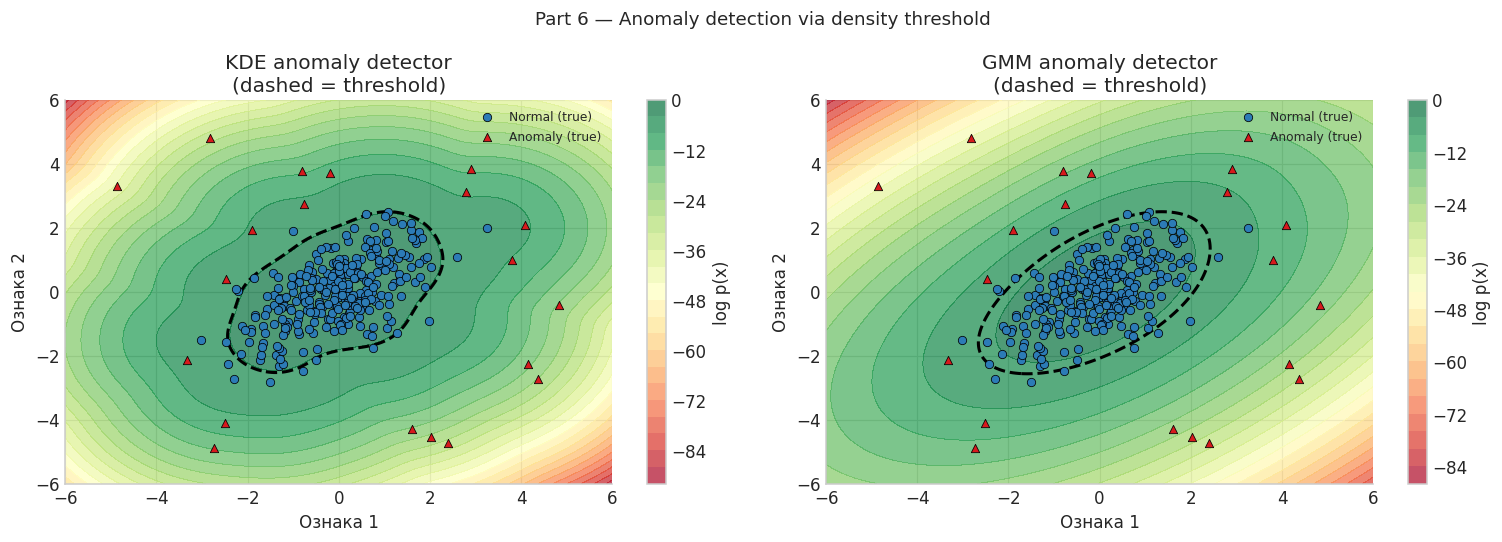

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

def anomaly_metrics(y_true, y_pred, name):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    print(f"{name:20s}  precision={p:.3f}  recall={r:.3f}  F1={f:.3f}")
    return p, r, f

print("Anomaly detection results:")
anomaly_metrics(y_true, y_pred_kde, "KDE detector")
anomaly_metrics(y_true, y_pred_gmm, "GMM detector")

# Anomaly score plots
x1g_a = np.linspace(-6, 6, 200)
x2g_a = np.linspace(-6, 6, 200)
X1A, X2A = np.meshgrid(x1g_a, x2g_a)
grid_a   = np.c_[X1A.ravel(), X2A.ravel()]

Z_kde_a = kde_ad.score_samples(grid_a).reshape(X1A.shape)
Z_gmm_a = gmm_ad.score_samples(grid_a).reshape(X1A.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, Z_log, tau, preds, title in zip(
    axes,
    [Z_kde_a, Z_gmm_a],
    [tau_kde, tau_gmm],
    [y_pred_kde, y_pred_gmm],
    ["KDE anomaly detector", "GMM anomaly detector"]
):
    # Log-density background
    cf = ax.contourf(X1A, X2A, Z_log, levels=25, cmap="RdYlGn", alpha=0.7)
    ax.contour(X1A, X2A, Z_log, levels=[tau], colors="black",
               linewidths=2, linestyles="--")

    # Data points
    for label, col, marker, lbl in [
        (0, COLORS[0], "o", "Normal (true)"),
        (1, COLORS[1], "^", "Anomaly (true)"),
    ]:
        mask = y_true == label
        ax.scatter(X_all[mask, 0], X_all[mask, 1],
                   color=col, s=30, marker=marker, zorder=5,
                   edgecolors="black", linewidths=0.5, label=lbl)

    # Mark false negatives (anomalies missed)
    fn_mask = (y_true == 1) & (preds == 0)
    if fn_mask.any():
        ax.scatter(X_all[fn_mask, 0], X_all[fn_mask, 1],
                   color="black", s=80, marker="x", zorder=7,
                   linewidths=2, label="Missed anomalies")

    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_xlabel("Ознака 1"); ax.set_ylabel("Ознака 2")
    ax.set_title(f"{title}\n(dashed = threshold)")
    ax.legend(fontsize=8)
    plt.colorbar(cf, ax=ax).set_label("log p(x)")

plt.suptitle("Part 6 — Anomaly detection via density threshold", fontsize=12)
plt.tight_layout(); plt.show()

#### Результати Part 6

- Оскільки аномалії гарантовано знаходяться за межею 3-сигмової зони
  нормального кластера, детектор надійно їх знаходить: вони мають низьку
  оцінену щільність за визначенням.
- Поріг $\tau$ (пунктирна ізолінія) утворює "зону нормальності": точки
  всередині є нормальними, ззовні — аномаліями.
- **Ключовий висновок:** мітка "аномалія" в unsupervised детекції завжди
  означає "оцінена щільність нижча за поріг". Якби рівномірно згенерована
  точка потрапила всередину кластера, детектор правильно назвав би її
  нормальною — і це не помилка, а коректна поведінка: така точка дійсно
  нічим не відрізняється від нормальних.